# 0. google colab setup

In [1]:
import torch
torch.cuda.is_available()


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


ModuleNotFoundError: No module named 'google'

In [ ]:
!git clone https://github.com/matsellingsen/gensys_additional-experiment.git


In [ ]:
!pip install -r /content/gensys_additional-experiment/requirements.txt


In [ ]:
import os
import sys

ROBIN_ROOT = "/content/gensys_additional-experiment/robin"

os.chdir(ROBIN_ROOT)

if ROBIN_ROOT not in sys.path:
    sys.path.insert(0, ROBIN_ROOT)

print("CWD:", os.getcwd())
print("data_utils exists:", os.path.isdir("data_utils"))


# 1. setup

In [2]:
# imports

import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TextDataset, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments, LogitsProcessor
import torch.nn as nn
import numpy as np
import random
import os
import sys

#sys.path.append("..")

from data_utils.scan_helpers import (
    load_scan_split,
    build_vocab,
)

from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    ordered_sequence_token_accuracy,   
    evaluate_ordered_token_accuracy,
)

from result_utils.save_results import (
    save_experiment_results,
    load_experiment_results,
)

from result_utils.plot_results import (
    exp1_plot_sequence_accuracy,
    exp2_plot_sequence_accuracy,
    exp2_plot_token_accuracy,
)

RuntimeError: Only a single TORCH_LIBRARY can be used to register the namespace triton; please put all of your definitions in a single TORCH_LIBRARY block.  If you were trying to specify implementations, consider using TORCH_LIBRARY_IMPL (which can be duplicated).  If you really intended to define operators for a single namespace in a distributed way, you can use TORCH_LIBRARY_FRAGMENT to explicitly indicate this.  Previous registration of TORCH_LIBRARY was registered at c:\Users\MatsEllingsen\OneDrive - University of Copenhagen\UCPH\fall2025\ANLP\GenSys\.venv\Lib\site-packages\torch\__init__.py:2700; latest registration was registered at c:\Users\MatsEllingsen\OneDrive - University of Copenhagen\UCPH\fall2025\ANLP\GenSys\.venv\Lib\site-packages\torch\__init__.py:2700

In [3]:
#Load pre-trained model and tokenizer

model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name, padding_side='left')
# Add special tokens to GPT-2 tokenizer
special_tokens = ["<SEP>", "<EOS>"]
tokenizer.add_tokens(special_tokens)
# Set pad token to avoid warnings (use EOS as pad)
tokenizer.pad_token = tokenizer.eos_token


model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

NameError: name 'GPT2Tokenizer' is not defined

In [ ]:
# Adapt data for gpt-2 decoder-only architecture
def adapt_for_gpt2(sequence):
    """
    Convert SCAN sequence from 'IN: command OUT: actions' format to GPT-2 format.
    Format: 'command <SEP> actions <EOS>'
    """
    # Parse the sequence - format is "IN: input OUT: output"
    parts = sequence.split(" OUT: ")
    if len(parts) != 2:
        return None
    
    input_part = parts[0].replace("IN: ", "").strip()
    output_part = parts[1].strip()
    
    # Format for GPT-2: input <SEP> output <EOS>
    formatted = f"{input_part} <SEP> {output_part} <EOS>"
    return formatted

def create_gpt2_dataset_file(data_path, output_path):
    """
    Create a dataset file in the format GPT-2 can fine-tune on.
    """
    lines = []
    with open(data_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                formatted = adapt_for_gpt2(line)
                if formatted:
                    lines.append(formatted)
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, 'w') as f:
        for line in lines:
            f.write(line + "\n")
    
    return len(lines)

In [ ]:
"""percentages = [1, 2, 4, 8, 16, 32, 64, 100]

dataset_pairs = []
path_pairs = {"length_split": [], "simple_split": []}
def create_and_save_adapted_datasets(type: str):
    if type == "simple_split":
        for percentage_cmds_used in percentages:
            if percentage_cmds_used == 100:
                train_path = "data/simple_split/tasks_train_simple.txt"
                test_path  = "data/simple_split/tasks_test_simple.txt"
            else:
                train_path = f"data/simple_split/size_variations/tasks_train_simple_p{percentage_cmds_used}.txt"
                test_path  = f"data/simple_split/size_variations/tasks_test_simple_p{percentage_cmds_used}.txt"
            #dataset_pairs.append((percentage_cmds_used, train_path, test_path))

            output_train_path = f"data/gpt2_finetune/simple_split/train_p{percentage_cmds_used}.txt"
            output_test_path  = f"data/gpt2_finetune/simple_split/test_p{percentage_cmds_used}.txt"

            create_gpt2_dataset_file(train_path, output_train_path)
            create_gpt2_dataset_file(test_path, output_test_path)

            path_pairs["simple_split"].append((percentage_cmds_used, output_train_path, output_test_path))

    elif type == "length_split":
        train_path = "data/length_split/tasks_train_length.txt"
        test_path  = "data/length_split/tasks_test_length.txt"

        output_train_path = f"data/gpt2_finetune/length_split/train_length.txt"
        output_test_path  = f"data/gpt2_finetune/length_split/test_length.txt"
        create_gpt2_dataset_file(train_path, output_train_path)
        create_gpt2_dataset_file(test_path, output_test_path)

        path_pairs["length_split"].append((output_train_path, output_test_path))

create_and_save_adapted_datasets("simple_split")
create_and_save_adapted_datasets("length_split")
"""

In [ ]:
percentages = [1, 2, 4, 8, 16, 32, 64, 100]

dataset_pairs = []
path_pairs = {"length_split": [], "simple_split": []}
def create_and_save_adapted_datasets(type: str):
    if type == "simple_split":
        for percentage_cmds_used in percentages:
            if percentage_cmds_used == 100:
                train_path = "experiments/data/simple_split/tasks_train_simple.txt"
                test_path  = "experiments/data/simple_split/tasks_test_simple.txt"
            else:
                train_path = f"experiments/data/simple_split/size_variations/tasks_train_simple_p{percentage_cmds_used}.txt"
                test_path  = f"experiments/data/simple_split/size_variations/tasks_test_simple_p{percentage_cmds_used}.txt"

            #dataset_pairs.append((percentage_cmds_used, train_path, test_path))

            output_train_path = f"experiments/data/gpt2_finetune/simple_split/train_p{percentage_cmds_used}.txt"
            output_test_path  = f"experiments/data/gpt2_finetune/simple_split/test_p{percentage_cmds_used}.txt"

            create_gpt2_dataset_file(train_path, output_train_path)
            create_gpt2_dataset_file(test_path, output_test_path)

            path_pairs["simple_split"].append((percentage_cmds_used, output_train_path, output_test_path))

    elif type == "length_split":
        train_path = "experiments/data/length_split/tasks_train_length.txt"
        test_path  = "experiments/data/length_split/tasks_test_length.txt"

        output_train_path = f"experiments/data/gpt2_finetune/length_split/train_length.txt"
        output_test_path  = f"experiments/data/gpt2_finetune/length_split/test_length.txt"
        create_gpt2_dataset_file(train_path, output_train_path)
        create_gpt2_dataset_file(test_path, output_test_path)

        path_pairs["length_split"].append((output_train_path, output_test_path))

create_and_save_adapted_datasets("simple_split")
create_and_save_adapted_datasets("length_split")

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/data/simple_split/size_variations/tasks_train_simple_p1.txt'

In [ ]:
# Fine-tuning hyperparameters
# Configured to match original Transformer experiments by matching TRAINING STEPS, not total samples
# This prevents overfitting on small datasets while maintaining comparability

SEED_BASE = 42

# Simple split config (matching Experiment 1)
SIMPLE_SPLIT_DROPOUT = 0.05
SIMPLE_SPLIT_BATCH_SIZE = 64
SIMPLE_SPLIT_MAX_STEPS = 100_000 // SIMPLE_SPLIT_BATCH_SIZE  # 1,562 steps
SIMPLE_SPLIT_LR = 7e-4
SIMPLE_SPLIT_MAX_EPOCHS = 15  # Safety cap to prevent overfitting on tiny datasets

# Length split config (matching Experiment 2)
LENGTH_SPLIT_DROPOUT = 0.15
LENGTH_SPLIT_BATCH_SIZE = 16
LENGTH_SPLIT_MAX_STEPS = 100_000 // LENGTH_SPLIT_BATCH_SIZE  # 6,250 steps
LENGTH_SPLIT_LR = 2e-4
LENGTH_SPLIT_MAX_EPOCHS = 15  # Safety cap

WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
NUM_RUNS = 1  # for testing
#NUM_RUNS = 5  # Number of runs for statistical robustness

def tokenize_action_sequence(sequence_str):
    """Convert a space-separated action sequence string to a list of tokens."""
    return sequence_str.strip().split()

class OracleLengthLogitsProcessor(LogitsProcessor):
    """
    Logits processor that enforces oracle length constraints.
    Matches the oracle behavior from the original Transformer experiments:
    - Forbids EOS before reaching target_length tokens (step + 1 < target_length)
    - Forces EOS at exactly target_length tokens (step + 1 >= target_length)
    """
    def __init__(self, target_length, eos_token_id, start_length):
        super().__init__()
        self.target_length = target_length  # Number of BPE tokens to generate (including <EOS>)
        self.eos_token_id = eos_token_id
        self.start_length = start_length  # Length of input prompt
    
    def __call__(self, input_ids, scores):
        # Current generation step (0-indexed, counts how many tokens already generated)
        # This matches 'step' in the original greedy_decode function
        step = input_ids.shape[1] - self.start_length
        device = scores.device
        
        # Original logic: step + 1 represents the position of the token we're about to generate
        # Too early: forbid EOS (when step + 1 < target_length)
        if step + 1 < self.target_length:
            scores[:, self.eos_token_id] = float('-inf')
        
        # At or after target length: force EOS (when step + 1 >= target_length)
        elif step + 1 >= self.target_length:
            # Set all non-EOS tokens to very low probability
            scores[:] = float('-inf')
            scores[:, self.eos_token_id] = 0.0
        
        return scores

def generate_with_oracle(model, tokenizer, input_ids, expected_output_str, eos_token_id):
    """
    Generate with oracle length constraints (matches oracle behavior from Transformer experiments).
    
    CRITICAL: Uses BPE token count (not action-level tokens) for length constraint,
    matching how the original Transformer's greedy_decode uses target_output_lengths.
    
    Args:
        model: GPT-2 model
        tokenizer: GPT-2 tokenizer
        input_ids: Input tensor
        expected_output_str: The expected output string (e.g., "WALK LTURN WALK")
        eos_token_id: ID of the <EOS> token
    
    Returns:
        Generated output string
    """
    from transformers import LogitsProcessorList
    
    # CRITICAL FIX: Count BPE tokens (not action tokens) to match original Transformer behavior
    # The original uses: target_output_lengths = (target_output != PAD).sum(dim=1)
    # which counts the actual number of tokens in the target sequence (including EOS)
    expected_output_with_eos = expected_output_str + " <EOS>"
    expected_tokens = tokenizer.encode(expected_output_with_eos, add_special_tokens=False)
    target_length = len(expected_tokens)  # Number of BPE tokens including <EOS>
    
    # Create oracle logits processor
    oracle_processor = OracleLengthLogitsProcessor(
        target_length=target_length,
        eos_token_id=eos_token_id,
        start_length=input_ids.shape[1]
    )
    
    with torch.no_grad():
        generated = model.generate(
            input_ids,
            max_new_tokens=target_length + 2,  # Small buffer
            num_beams=1,
            do_sample=False,
            logits_processor=LogitsProcessorList([oracle_processor]),
            pad_token_id=tokenizer.pad_token_id,
        )
    
    # Extract output after <SEP>
    generated_text = tokenizer.decode(generated[0], skip_special_tokens=False)
    if " <SEP> " in generated_text:
        output_part = generated_text.split(" <SEP> ")[1].replace(" <EOS>", "").strip()
    else:
        output_part = ""
    
    return output_part

def fine_tune_and_evaluate_gpt2(train_file, test_file, split_name, batch_size, max_steps, 
                                  max_epochs, learning_rate, dropout_prob, run_seed=None, 
                                  use_oracle=False, split_by_length=False, output_dir="gpt2_finetuned"):
    """
    Fine-tune and evaluate GPT-2 on a specific SCAN split.
    Uses max_steps (matching original Transformer experiments) with an epoch cap to prevent overfitting.
    
    Args:
        batch_size: Training batch size (from config)
        max_steps: Maximum training steps to match original experiments
        max_epochs: Maximum epochs to prevent overfitting on small datasets
        learning_rate: Learning rate (from config)
        dropout_prob: Dropout probability for the model
    
    Returns:
        Dictionary with evaluation results (sequence and token accuracy)
    """
    seed = run_seed if run_seed is not None else SEED_BASE
    
    oracle_str = "with oracle" if use_oracle else "without oracle"
    print(f"\n{'='*60}")
    print(f"Fine-tuning GPT-2 on {split_name} (seed={seed}, {oracle_str})")
    print(f"{'='*60}")
    
    # Set seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    # Determine device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Create model and resize embeddings to include new tokens
    model = GPT2LMHeadModel.from_pretrained("gpt2")
    model.resize_token_embeddings(len(tokenizer))
    
    # Apply dropout to model config
    model.config.dropout = dropout_prob
    model.config.attn_pdrop = dropout_prob
    model.config.embd_pdrop = dropout_prob
    model.config.resid_pdrop = dropout_prob
    
    model.to(device)
    
    # Create datasets
    train_dataset = TextDataset(
        tokenizer=tokenizer,
        file_path=train_file,
        block_size=128,
    )
    
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False,
    )
    
    # Calculate actual training configuration
    steps_per_epoch = len(train_dataset) // batch_size
    epochs_for_max_steps = (max_steps + steps_per_epoch - 1) // steps_per_epoch
    actual_epochs = min(epochs_for_max_steps, max_epochs)
    actual_max_steps = min(max_steps, actual_epochs * steps_per_epoch)
    
    print(f"Training configuration:")
    print(f"  Dataset size: {len(train_dataset)} samples")
    print(f"  Batch size: {batch_size}")
    print(f"  Steps per epoch: {steps_per_epoch}")
    print(f"  Target max steps: {max_steps}")
    print(f"  Epochs needed for max steps: {epochs_for_max_steps}")
    print(f"  Epoch cap: {max_epochs}")
    print(f"  Actual epochs: {actual_epochs}")
    print(f"  Actual max steps: {actual_max_steps}")
    print(f"  Learning rate: {learning_rate}")
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"{output_dir}_{split_name}",
        overwrite_output_dir=True,
        max_steps=actual_max_steps,  # Use steps to match original experiments
        num_train_epochs=actual_epochs,  # Capped to prevent overfitting
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        save_steps=max(1, actual_max_steps // 5),
        save_total_limit=1,
        learning_rate=learning_rate,
        warmup_steps=min(WARMUP_STEPS, actual_max_steps // 10),
        weight_decay=WEIGHT_DECAY,
        max_grad_norm=GRAD_CLIP,
        logging_steps=max(1, actual_max_steps // 20),
        seed=seed,
        disable_tqdm=False,
        report_to="none"
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=data_collator,
        train_dataset=train_dataset,
    )
    
    # Train
    trainer.train()
    
    print(f"Fine-tuning on {split_name} completed!")
    print(f"\nEvaluating on {split_name} ({oracle_str})...")
    
    # Evaluate using the proven evaluation logic from original experiments
    model.eval()
    
    if split_by_length:
        # For length split: organize by source and target length
        results_by_source_length = {}
        results_by_target_length = {}
    else:
        # For simple split: overall metrics
        all_seq_matches = []
        all_token_accs = []
    
    eos_token_id = tokenizer.convert_tokens_to_ids("<EOS>")
    
    # Load all test samples
    test_samples = []
    with open(test_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # Parse input and expected output
            parts = line.split(" <SEP> ")
            if len(parts) != 2:
                continue
            
            input_text = parts[0]
            expected_output = parts[1].replace(" <EOS>", "").strip()
            
            # Calculate lengths
            input_tokens = tokenize_action_sequence(input_text)
            target_tokens = tokenize_action_sequence(expected_output)
            source_length = len(input_tokens)
            target_length = len(target_tokens)
            
            test_samples.append({
                "input_text": input_text,
                "expected_output": expected_output,
                "source_length": source_length,
                "target_length": target_length,
                "target_tokens": target_tokens,
            })
    
    # Batch generation
    eval_batch_size = 128
    num_batches = (len(test_samples) + eval_batch_size - 1) // eval_batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * eval_batch_size
        end_idx = min((batch_idx + 1) * eval_batch_size, len(test_samples))
        batch_samples = test_samples[start_idx:end_idx]
        
        # Prepare batch inputs
        input_texts = [s["input_text"] + " <SEP>" for s in batch_samples]
        encoded = tokenizer(input_texts, return_tensors="pt", padding=True, truncation=True)
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        # Generate outputs
        if use_oracle:
            # Oracle mode: process one by one (since target lengths differ)
            generated_outputs = []
            for i, sample in enumerate(batch_samples):
                single_input_ids = input_ids[i:i+1]
                # Pass the expected output string so oracle can count BPE tokens correctly
                gen_output = generate_with_oracle(
                    model, tokenizer, single_input_ids, sample["expected_output"], eos_token_id
                )
                generated_outputs.append(gen_output)
        else:
            with torch.no_grad():
                output_ids = model.generate(
                    input_ids,
                    attention_mask=attention_mask,
                    max_length=input_ids.shape[1] + 50,
                    num_beams=1,
                    early_stopping=True,
                    eos_token_id=eos_token_id,
                    pad_token_id=tokenizer.pad_token_id,
                )
            
            # Decode batch outputs
            generated_outputs = []
            for i in range(len(batch_samples)):
                generated_text = tokenizer.decode(output_ids[i], skip_special_tokens=False)
                
                # Extract only the output part (after <SEP>)
                if " <SEP> " in generated_text:
                    generated_output = generated_text.split(" <SEP> ")[1].replace(" <EOS>", "").strip()
                else:
                    generated_output = ""
                generated_outputs.append(generated_output)
        
        # Process batch results using proven evaluation logic
        for sample, generated_output in zip(batch_samples, generated_outputs):
            expected_output = sample["expected_output"]
            target_tokens = sample["target_tokens"]
            source_length = sample["source_length"]
            target_length = sample["target_length"]
            
            # Parse predicted tokens
            predicted_tokens = tokenize_action_sequence(generated_output) if generated_output else []
            
            # PROVEN EVALUATION LOGIC from original experiments:
            # 1. Sequence accuracy: exact string match
            seq_match = 1.0 if generated_output == expected_output else 0.0
            
            # 2. Token accuracy: position-wise comparison with partial credit
            # This matches ordered_sequence_token_accuracy from scan_evaluation.py
            if not target_tokens:
                token_acc = 0.0
            else:
                total_correct = 0
                total_tokens = 0
                    
                # Compare position-wise
                L = min(len(predicted_tokens), len(target_tokens))
                for i in range(L):
                    if predicted_tokens[i] == target_tokens[i]:
                        total_correct += 1
                    total_tokens += 1
                
                # If prediction is shorter than target, remaining tokens count as incorrect
                total_tokens += max(0, len(target_tokens) - L)
                
                token_acc = total_correct / total_tokens if total_tokens > 0 else 0.0
            
            if split_by_length:
                # Store by source length
                if source_length not in results_by_source_length:
                    results_by_source_length[source_length] = {"seq": [], "tok": []}
                results_by_source_length[source_length]["seq"].append(seq_match)
                results_by_source_length[source_length]["tok"].append(token_acc)
                
                # Store by target length
                if target_length not in results_by_target_length:
                    results_by_target_length[target_length] = {"seq": [], "tok": []}
                results_by_target_length[target_length]["seq"].append(seq_match)
                results_by_target_length[target_length]["tok"].append(token_acc)
            else:
                all_seq_matches.append(seq_match)
                all_token_accs.append(token_acc)
        
        if not split_by_length and (batch_idx + 1) % 10 == 0:
            print(f"  Processed {end_idx}/{len(test_samples)} samples...")
    
    if split_by_length:
        # Aggregate results by length
        result = {
            "source_length": {},
            "target_length": {},
        }
        
        for length, metrics in results_by_source_length.items():
            result["source_length"][length] = {
                "seq": float(np.mean(metrics["seq"])),
                "tok": float(np.mean(metrics["tok"])),
            }
        
        for length, metrics in results_by_target_length.items():
            result["target_length"][length] = {
                "seq": float(np.mean(metrics["seq"])),
                "tok": float(np.mean(metrics["tok"])),
            }
        
        print(f"Evaluated on {len(results_by_source_length)} source lengths, {len(results_by_target_length)} target lengths")
    else:
        seq_accuracy = float(np.mean(all_seq_matches)) if all_seq_matches else 0.0
        avg_token_accuracy = float(np.mean(all_token_accs)) if all_token_accs else 0.0
        
        print(f"Sequence accuracy: {seq_accuracy*100:.2f}%")
        print(f"Token accuracy: {avg_token_accuracy*100:.2f}%")
        
        result = {
            "seq": seq_accuracy,
            "tok": avg_token_accuracy,
        }
    
    # Clean up model to save memory
    del model
    del trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return result

: 

In [ ]:
# Fine-tune and evaluate on simple split (multiple runs for statistical robustness)
results_simple = {}

print(f"\n{'='*80}")
print(f"EXPERIMENT: Simple Split with varying training data sizes")
print(f"Matching original Experiment 1 training procedure:")
print(f"  Batch size: {SIMPLE_SPLIT_BATCH_SIZE}")
print(f"  Max steps: {SIMPLE_SPLIT_MAX_STEPS} (same as original {100_000}/{SIMPLE_SPLIT_BATCH_SIZE})")
print(f"  Max epochs: {SIMPLE_SPLIT_MAX_EPOCHS} (cap to prevent overfitting)")
print(f"Running {NUM_RUNS} times per configuration for statistical robustness")
print(f"{'='*80}")

for percentage, train_data_simple, test_data_simple in path_pairs["simple_split"]:
    #if percentage != 1: # for testing purposes, only run for 1%
    #    break
    print(f"\n{'='*60}")
    print(f"Processing: {percentage}% of commands")
    print(f"{'='*60}")
    
    run_results = []
    
    for run_idx in range(1, NUM_RUNS + 1):
        print(f"\n--- Run {run_idx}/{NUM_RUNS} ---")
        
        run_seed = SEED_BASE + run_idx
        result = fine_tune_and_evaluate_gpt2(
            train_file=train_data_simple,
            test_file=test_data_simple,
            split_name=f"simple_split_p{percentage}_run{run_idx}",
            batch_size=SIMPLE_SPLIT_BATCH_SIZE,
            max_steps=SIMPLE_SPLIT_MAX_STEPS,
            max_epochs=SIMPLE_SPLIT_MAX_EPOCHS,
            learning_rate=SIMPLE_SPLIT_LR,
            dropout_prob=SIMPLE_SPLIT_DROPOUT,
            run_seed=run_seed,
        )
        run_results.append(result)
    
    # Calculate statistics across runs
    seq_vals = np.array([r["seq"] for r in run_results])
    tok_vals = np.array([r["tok"] for r in run_results])
    
    results_simple[percentage] = {
        "seq": {
            "mean": float(seq_vals.mean()),
            "std": float(seq_vals.std(ddof=1)),
            "runs": seq_vals.tolist(),
        },
        "tok": {
            "mean": float(tok_vals.mean()),
            "std": float(tok_vals.std(ddof=1)),
            "runs": tok_vals.tolist(),
        },
    }
    
    print(f"\n{'='*60}")
    print(f"Results for {percentage}%:")
    print(f"  Sequence Acc: {seq_vals.mean()*100:.2f}% ± {seq_vals.std(ddof=1)*100:.2f}%")
    print(f"  Token Acc:    {tok_vals.mean()*100:.2f}% ± {tok_vals.std(ddof=1)*100:.2f}%")
    print(f"{'='*60}")

print(f"\n{'='*80}")
print(f"Simple Split Experiment Complete!")
print(f"{'='*80}")



EXPERIMENT: Simple Split with varying training data sizes
Running 1 times per configuration for statistical robustness

Processing: 1% of commands

--- Run 1/1 ---

Fine-tuning GPT-2 on simple_split_p1_run1 (seed=43, without oracle)


c:\Users\MatsEllingsen\OneDrive - University of Copenhagen\UCPH\fall2025\ANLP\GenSys\.venv\Lib\site-packages\transformers\data\datasets\language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
c:\Users\MatsEllingsen\OneDrive - University of Copenhagen\UCPH\fall2025\ANLP\GenSys\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
# Fine-tune and evaluate on length split (with and without oracle)
train_data_length = path_pairs["length_split"][0][0]
test_data_length = path_pairs["length_split"][0][1]

print(f"\n{'='*80}")
print(f"EXPERIMENT: Length Split")
print(f"Running {NUM_RUNS} times for statistical robustness")
print(f"Evaluating both WITH and WITHOUT oracle")
print(f"{'='*80}")

results_length = []

for run_idx in range(1, NUM_RUNS + 1):
    print(f"\n{'='*70}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*70}")
    
    run_seed = SEED_BASE + run_idx
    
    # Train once, then evaluate with both oracle modes
    print("\n--- Training model ---")
    
    # We need to train the model once and keep it for both evaluations
    # So we'll modify approach: train separately, then evaluate twice
    
    # For now, let's do two separate training runs (one per oracle mode)
    # This matches the original approach where evaluation is done after training
    
    run_result = {
        "source_length": {"without_oracle": {}, "with_oracle": {}},
        "target_length": {"without_oracle": {}, "with_oracle": {}},
    }
    
    # Evaluate WITHOUT oracle
    print("\n--- Evaluating WITHOUT oracle ---")
    result_no_oracle = fine_tune_and_evaluate_gpt2(
        train_file=train_data_length,
        test_file=test_data_length,
        split_name=f"length_split_run{run_idx}_no_oracle",
        run_seed=run_seed,
        use_oracle=False,
        split_by_length=True,
        train_batch_size=16,
        lr=2e-4,
    )
    
    # Evaluate WITH oracle (need to retrain with same seed)
    print("\n--- Evaluating WITH oracle ---")
    result_with_oracle = fine_tune_and_evaluate_gpt2(
        train_file=train_data_length,
        test_file=test_data_length,
        split_name=f"length_split_run{run_idx}_with_oracle",
        run_seed=run_seed,
        use_oracle=True,
        split_by_length=True,
    )
    
    # Merge results
    run_result["source_length"]["without_oracle"] = result_no_oracle["source_length"]
    run_result["source_length"]["with_oracle"] = result_with_oracle["source_length"]
    run_result["target_length"]["without_oracle"] = result_no_oracle["target_length"]
    run_result["target_length"]["with_oracle"] = result_with_oracle["target_length"]
    
    results_length.append(run_result)

# Aggregate results across runs (matching experiment 2 format)
final_results_length = {
    "source_length": {"without_oracle": {}, "with_oracle": {}},
    "target_length": {"without_oracle": {}, "with_oracle": {}},
}

for split_type in ["source_length", "target_length"]:
    for oracle_flag in ["without_oracle", "with_oracle"]:
        # Get all lengths from first run
        lengths = results_length[0][split_type][oracle_flag].keys()
        
        for length in lengths:
            seq_vals = [
                run[split_type][oracle_flag][length]["seq"]
                for run in results_length
                if length in run[split_type][oracle_flag]
            ]
            tok_vals = [
                run[split_type][oracle_flag][length]["tok"]
                for run in results_length
                if length in run[split_type][oracle_flag]
            ]
            
            seq_vals = np.array(seq_vals)
            tok_vals = np.array(tok_vals)
            
            final_results_length[split_type][oracle_flag][length] = {
                "seq": {
                    "runs": seq_vals.tolist(),
                    "mean": float(seq_vals.mean()),
                    "std": float(seq_vals.std(ddof=1)),
                    "sem": float(seq_vals.std(ddof=1) / np.sqrt(NUM_RUNS)),
                },
                "tok": {
                    "runs": tok_vals.tolist(),
                    "mean": float(tok_vals.mean()),
                    "std": float(tok_vals.std(ddof=1)),
                    "sem": float(tok_vals.std(ddof=1) / np.sqrt(NUM_RUNS)),
                },
            }

print(f"\n{'='*80}")
print(f"Length Split Experiment Complete!")
print(f"{'='*80}")

IndexError: list index out of range

# Results Summary

In [ ]:
# Display Simple Split Results
print("\n" + "="*80)
print("SIMPLE SPLIT RESULTS SUMMARY")
print("="*80)
print(f"{'% Commands':<15} {'Seq Acc (Mean)':<20} {'Token Acc (Mean)':<20}")
print("-"*80)

for percentage in sorted(results_simple.keys()):
    seq_mean = results_simple[percentage]["seq"]["mean"] * 100
    seq_std = results_simple[percentage]["seq"]["std"] * 100
    tok_mean = results_simple[percentage]["tok"]["mean"] * 100
    tok_std = results_simple[percentage]["tok"]["std"] * 100
    
    print(f"{percentage:<15} {seq_mean:6.2f}% ± {seq_std:5.2f}%    {tok_mean:6.2f}% ± {tok_std:5.2f}%")

print("\n" + "="*80)
print("LENGTH SPLIT RESULTS SUMMARY")
print("="*80)

# Display results by source length
for oracle_flag in ["without_oracle", "with_oracle"]:
    print(f"\n{oracle_flag.replace('_', ' ').upper()}:")
    print("-"*80)
    
    print("\nBy Source Length:")
    print(f"{'Length':<10} {'Seq Acc':<20} {'Token Acc':<20}")
    for length in sorted(final_results_length["source_length"][oracle_flag].keys()):
        seq_mean = final_results_length["source_length"][oracle_flag][length]["seq"]["mean"] * 100
        seq_std = final_results_length["source_length"][oracle_flag][length]["seq"]["std"] * 100
        tok_mean = final_results_length["source_length"][oracle_flag][length]["tok"]["mean"] * 100
        tok_std = final_results_length["source_length"][oracle_flag][length]["tok"]["std"] * 100
        print(f"{length:<10} {seq_mean:5.2f}% ± {seq_std:4.2f}%    {tok_mean:5.2f}% ± {tok_std:4.2f}%")
    
    print("\nBy Target Length:")
    print(f"{'Length':<10} {'Seq Acc':<20} {'Token Acc':<20}")
    for length in sorted(final_results_length["target_length"][oracle_flag].keys()):
        seq_mean = final_results_length["target_length"][oracle_flag][length]["seq"]["mean"] * 100
        seq_std = final_results_length["target_length"][oracle_flag][length]["seq"]["std"] * 100
        tok_mean = final_results_length["target_length"][oracle_flag][length]["tok"]["mean"] * 100
        tok_std = final_results_length["target_length"][oracle_flag][length]["tok"]["std"] * 100
        print(f"{length:<10} {seq_mean:5.2f}% ± {seq_std:4.2f}%    {tok_mean:5.2f}% ± {tok_std:4.2f}%")

print("\n" + "="*80)

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/gpt2_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [11]:
# Save results using the same format as experiments 1 & 2
save_experiment_results(
    results=results_simple,
    filename=OUTPUT_DIR + "/gpt2_experiment_simple_split",
    experiment_nr="GPT2_Simple",
    description="GPT-2 Fine-tuning: Simple split with varying training data sizes",
)

save_experiment_results(
    results=final_results_length,
    filename=OUTPUT_DIR + "/gpt2_experiment_length_split",
    experiment_nr="GPT2_Length",
    description="GPT-2 Fine-tuning: Length split with oracle and without oracle evaluation",
)

print("Results saved!")

NameError: name 'save_experiment_results' is not defined

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# EXPERIMENT 1
def exp1_plot_ordered_token_accuracy_comparison(baseline_results, gpt2_results):
    """
    Plot ordered-token-level accuracy comparison between baseline and GPT-2.
    Creates grouped bar plot with two bars per training percentage.
    """
    percentages = sorted(baseline_results.keys(), key=int)
    
    print("keys baseline: ", baseline_results["1"].keys())
    baseline_accuracies = [baseline_results[p]["mean"] * 100 for p in percentages]
    gpt2_accuracies = [gpt2_results[p]["tok"]["mean"] * 100 for p in percentages]
    
    x = np.arange(len(percentages))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, baseline_accuracies, width, label='Encoder-Decoder Baseline', alpha=0.8)
    bars2 = ax.bar(x + width/2, gpt2_accuracies, width, label='Fine-Tuned GPT-2', alpha=0.8)
    
    ax.set_xlabel("Percentage of Commands Used for Training", fontsize=12)
    ax.set_ylabel("Token Accuracy (%)", fontsize=12)
    #ax.set_title("Experiment 1b: Token Accuracy vs Training Coverage", fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(percentages)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# EXPERIMENT 2
def _extract_exp2_means(final_results, split_type, oracle, metric):
    """
    metric: 'seq' or 'tok'
    """
    oracle_key = "with_oracle" if oracle else "without_oracle"
    data = final_results[split_type][oracle_key]
    
    lengths = sorted(data.keys())
    means = [data[L][metric]["mean"] * 100 for L in lengths]
    
    return lengths, means

def _plot_subplot(ax, baseline_results, gpt2_results, split_type, oracle, metric):
    """
    Helper function to plot a single subplot for experiment 2.
    """
    baseline_lengths, baseline_means = _extract_exp2_means(
        baseline_results, split_type=split_type, oracle=oracle, metric=metric
    )
    gpt2_lengths, gpt2_means = _extract_exp2_means(
        gpt2_results, split_type=split_type, oracle=oracle, metric=metric
    )
    
    x = np.arange(len(baseline_lengths))
    width = 0.35
    
    ax.bar(x - width/2, baseline_means, width, label='Baseline', alpha=0.8)
    ax.bar(x + width/2, gpt2_means, width, label='GPT-2', alpha=0.8)
    
    metric_name = "Sequence" if metric == "seq" else "Token"
    split_name = "Source" if split_type == "source_length" else "Target"
    
    ax.set_xlabel(f"{split_name} Length", fontsize=10)
    ax.set_ylabel(f"{metric_name} Acc (%)", fontsize=10)
    ax.set_title(f"{split_name} Length - {metric_name} Accuracy", fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_lengths, fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

def exp2_plot_all_without_oracle(baseline_results, gpt2_results):
    """
    Plot all 4 metrics for experiment 2 WITHOUT oracle in a 2x2 grid.
    Top row: source length (seq, tok)
    Bottom row: target length (seq, tok)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    #fig.suptitle("Experiment 2: Length Split WITHOUT Oracle", fontsize=16, fontweight='bold', y=0.995)
    
    # Top left: source length, sequence accuracy
    _plot_subplot(axes[0, 0], baseline_results, gpt2_results, "source_length", False, "seq")
    
    # Top right: source length, token accuracy
    _plot_subplot(axes[0, 1], baseline_results, gpt2_results, "source_length", False, "tok")
    
    # Bottom left: target length, sequence accuracy
    _plot_subplot(axes[1, 0], baseline_results, gpt2_results, "target_length", False, "seq")
    
    # Bottom right: target length, token accuracy
    _plot_subplot(axes[1, 1], baseline_results, gpt2_results, "target_length", False, "tok")
    
    plt.tight_layout()
    plt.show()

def exp2_plot_all_with_oracle(baseline_results, gpt2_results):
    """
    Plot all 4 metrics for experiment 2 WITH oracle in a 2x2 grid.
    Top row: source length (seq, tok)
    Bottom row: target length (seq, tok)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    #fig.suptitle("Experiment 2: Length Split WITH Oracle", fontsize=16, fontweight='bold', y=0.995)
    
    # Top left: source length, sequence accuracy
    _plot_subplot(axes[0, 0], baseline_results, gpt2_results, "source_length", True, "seq")
    
    # Top right: source length, token accuracy
    _plot_subplot(axes[0, 1], baseline_results, gpt2_results, "source_length", True, "tok")
    
    # Bottom left: target length, sequence accuracy
    _plot_subplot(axes[1, 0], baseline_results, gpt2_results, "target_length", True, "seq")
    
    # Bottom right: target length, token accuracy
    _plot_subplot(axes[1, 1], baseline_results, gpt2_results, "target_length", True, "tok")
    
    plt.tight_layout()
    plt.show()

keys baseline:  dict_keys(['mean', 'std', 'runs'])


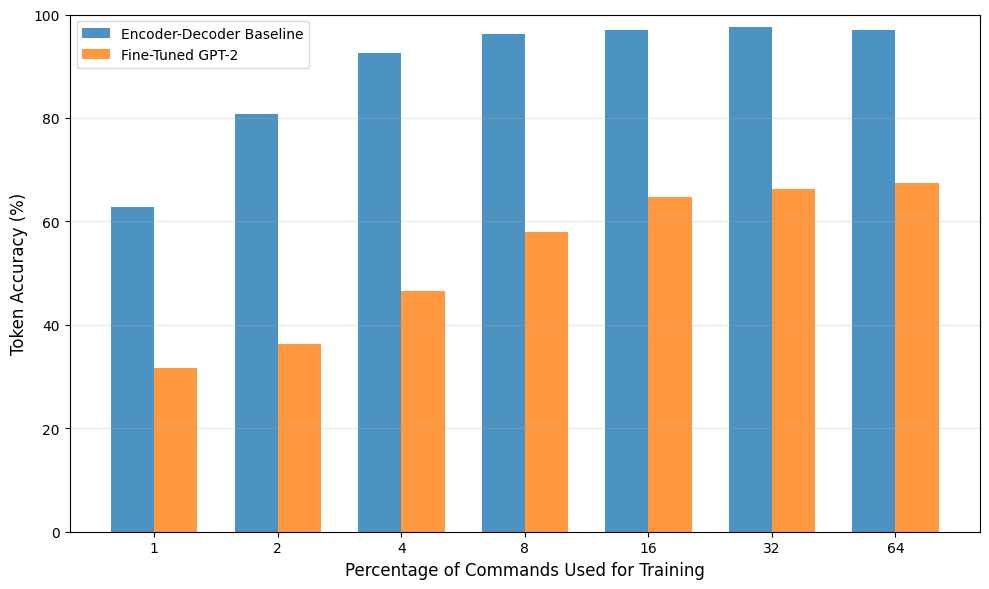

In [46]:
# Plot comparison for Experiment 1
import json
from pathlib import Path

# Load baseline results
baseline_exp1_path = Path(r"C:\Users\MatsEllingsen\onedrive - university of copenhagen\ucph\fall2025\anlp\gensys\robin\experiments\results\experiment_1\experiment_1_full.181220250025.json")
# Load GPT-2 results
gpt2_exp1_path = Path(r"C:\Users\MatsEllingsen\onedrive - university of copenhagen\ucph\fall2025\anlp\gensys\robin\experiments\results\additional_experiment\gpt2_experiment_simple_split.130120261511.json")

try:
    # Try to use in-memory results if available
    baseline_exp1 = results_simple_baseline["results"]
    gpt2_exp1 = results_simple["results"]
except NameError:
    # Load from files
    with open(baseline_exp1_path, 'r', encoding="utf-8") as f:
        baseline_exp1 = json.load(f)["results"]
    with open(gpt2_exp1_path, 'r', encoding="utf-8") as f:
        gpt2_exp1 = json.load(f)["results"]

# Create comparison plot
exp1_plot_ordered_token_accuracy_comparison(baseline_exp1, gpt2_exp1)

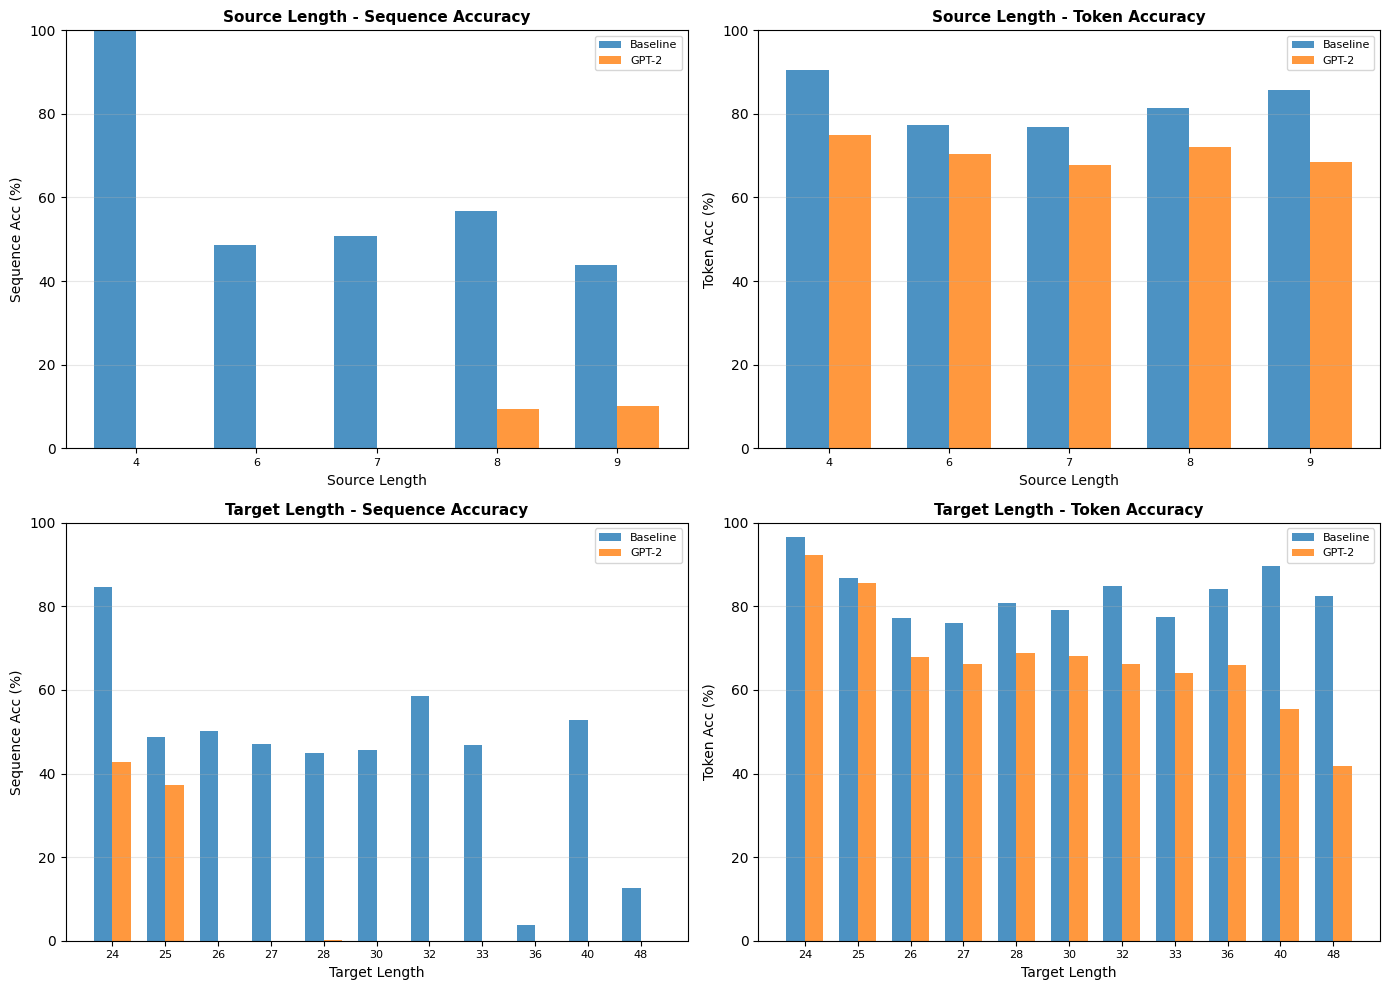

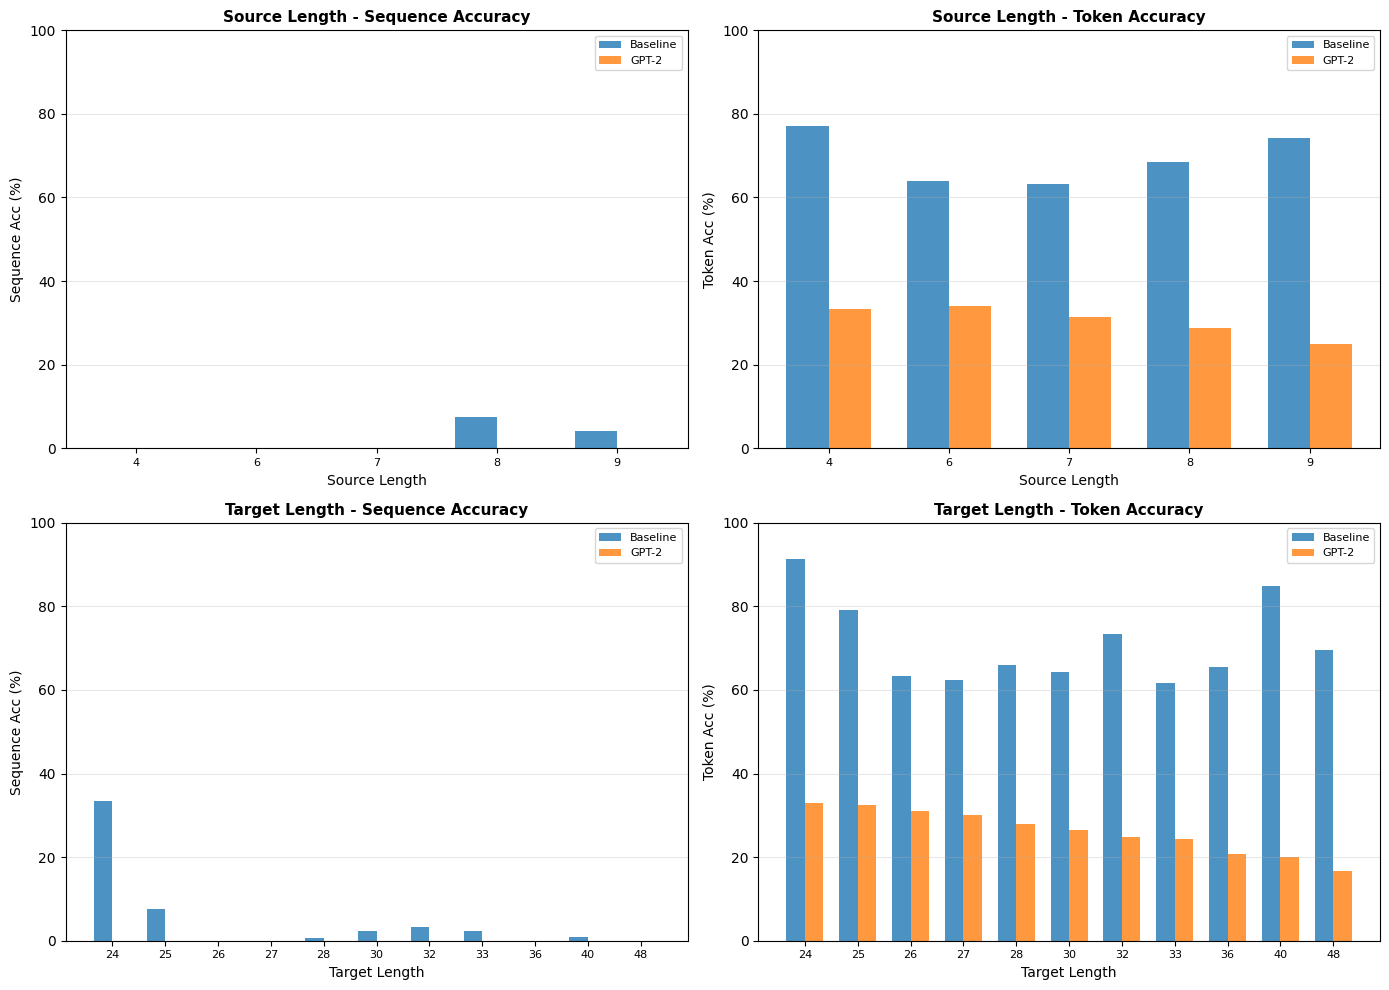

In [47]:
# Plot comparison for Experiment 2
import json
from pathlib import Path

# Load baseline results
baseline_exp2_path = Path(r"C:\Users\MatsEllingsen\onedrive - university of copenhagen\ucph\fall2025\anlp\gensys\robin\experiments\results\experiment_2\experiment_2_full.181220250249.json")
# Load GPT-2 results
gpt2_exp2_path = Path(r"C:\Users\MatsEllingsen\onedrive - university of copenhagen\ucph\fall2025\anlp\gensys\robin\experiments\results\additional_experiment\gpt2_experiment_length_split.130120261511.json")

try:
    # Try to use in-memory results if available
    baseline_exp2 = final_results_length_baseline["results"]
    gpt2_exp2 = final_results_length["results"]
except NameError:
    # Load from files
    with open(baseline_exp2_path, 'r', encoding="utf-8") as f:
        baseline_exp2 = json.load(f)["results"]
    with open(gpt2_exp2_path, 'r', encoding="utf-8") as f:
        gpt2_exp2 = json.load(f)["results"]

# Create comparison plots for all combinations

#WITH oracle
exp2_plot_all_with_oracle(baseline_exp2, gpt2_exp2)

#WITHOUT oracle
exp2_plot_all_without_oracle(baseline_exp2, gpt2_exp2)
